<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/rna-seq/10_harita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Harita: PCA ve ısı haritası

Sekizinci rehberde genleri tek tek yargıladık, dokuzuncuda takım takım sorguladık. Bu defterde kamerayı geri çekiyoruz: altı örneğin tamamını tek resimde göstermenin iki klasik yolu, PCA ve ısı haritası. İkisi de gözetimsizdir — kimin WT kimin KO olduğunu onlara söylemeyiz; verinin kendi kendini nasıl dizdiğine bakarız.

Kurulum yok; defter dakikalar içinde biter.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

t = pd.read_csv('https://raw.githubusercontent.com/melissa-04/melisayla-biyoinformatik/main/data/rna-seq/sayim_tablosu.csv')
ornekler = ['WT_1', 'WT_2', 'WT_3', 'KO_1', 'KO_2', 'KO_3']
g = t.set_index('gen_id')[ornekler]

poz = g[(g > 0).all(axis=1)]
logg = np.log(poz)
sf = np.exp(logg.sub(logg.mean(axis=1), axis=0).median(axis=0))
norm = g.div(sf, axis=1)
print('Cetvel yerinde:', sf.round(2).to_dict())

Cetvel yerinde: {'WT_1': 0.76, 'WT_2': 0.63, 'WT_3': 1.98, 'KO_1': 0.88, 'KO_2': 1.28, 'KO_3': 0.96}


## 1. Hazırlık

Üç karar, üç gerekçe. log1p alıyoruz, çünkü sayım verisi çarpıktır: birkaç dev gen logaritmasız resmi tek başına ele geçirir (+1, sıfırlar için). İfade tabanı koyuyoruz (ortalama ≥ 20), çünkü zar zor duyulan genlerin log-varyansı yapaydır. Ve en değişken 500 geni alıyoruz, çünkü örnekleri birbirinden ayıran şey değişen genlerdir; altı örnekte de aynı olan bir gen hiçbir eksen kuramaz.

In [2]:
sesli = norm[norm.mean(axis=1) >= 20]
ln = np.log1p(sesli)
degisken = ln.var(axis=1).sort_values(ascending=False)
ust = ln.loc[degisken.head(500).index]
print(len(sesli), 'gen tabanı geçti; PCA girdisi:', ust.shape[0], 'gen ×', ust.shape[1], 'örnek')

14069 gen tabanı geçti; PCA girdisi: 500 gen × 6 örnek


## 2. PCA üç cümlede

Her örneği, 500 genlik bir uzayda bir nokta olarak düşünün. PCA, bu noktaların en çok yayıldığı yönleri bulur ve onları sırayla eksen yapar; her eksenin yanına toplam varyansın yüzde kaçını taşıdığını yazar. Hesabın tamamı iki satırdır: merkezle, SVD al.

In [3]:
X = ust.T - ust.T.mean(axis=0)
U, S, Vt = np.linalg.svd(X, full_matrices=False)

pay = S**2 / (S**2).sum() * 100
PC = pd.DataFrame(U * S, index=ornekler, columns=[f'PC{i+1}' for i in range(len(S))])
print('Varyans payları (%):', pay[:3].round(1))
print(PC[['PC1', 'PC2', 'PC3']].round(1))

Varyans payları (%): [45.8 27.3 10.9]
       PC1   PC2   PC3
WT_1 -22.1   2.7  16.4
WT_2 -28.2 -26.8 -12.2
WT_3 -19.4  31.2  -5.3
KO_1  25.7  -5.0  -8.4
KO_2  25.6  10.3  -5.9
KO_3  18.4 -12.3  15.5


## 3. İlk okuma

PC1 sütununun işaretlerine bakın ve kimin kiminle durduğunu not edin — WT_3'ün nerede oturduğuna özellikle. Altı rehberdir uğraştığımız derinlik farkı bir eksen kuramadıysa, sebebi ilk hücrede: cetvel. PC2 ile PC3'ün kim olduğu ise şimdilik açık bir soru; grafikten sonra döneceğiz.

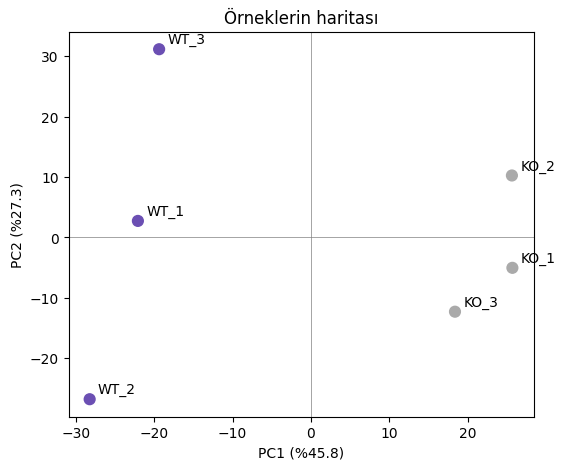

In [4]:
plt.figure(figsize=(6, 5))
renk = ['#6B4FB3'] * 3 + ['#AAAAAA'] * 3
plt.scatter(PC['PC1'], PC['PC2'], s=60, c=renk)
for s in ornekler:
    plt.annotate(s, (PC.loc[s, 'PC1'], PC.loc[s, 'PC2']),
                 textcoords='offset points', xytext=(6, 4))
plt.axhline(0, lw=0.5, c='gray'); plt.axvline(0, lw=0.5, c='gray')
plt.xlabel(f'PC1 (%{pay[0]:.1f})'); plt.ylabel(f'PC2 (%{pay[1]:.1f})')
plt.title('Örneklerin haritası');

## 4. Isı haritası

İkinci resim gen düzeyine iner: satırlar en değişken 30 gen, sütunlar örnekler. Her satırı kendi içinde z-skoruna çeviriyoruz — her genin kendi ölçeği vardır; mutlak değere değil desene bakıyoruz: hangi gen hangi örneklerde yüksek, hangilerinde düşük.

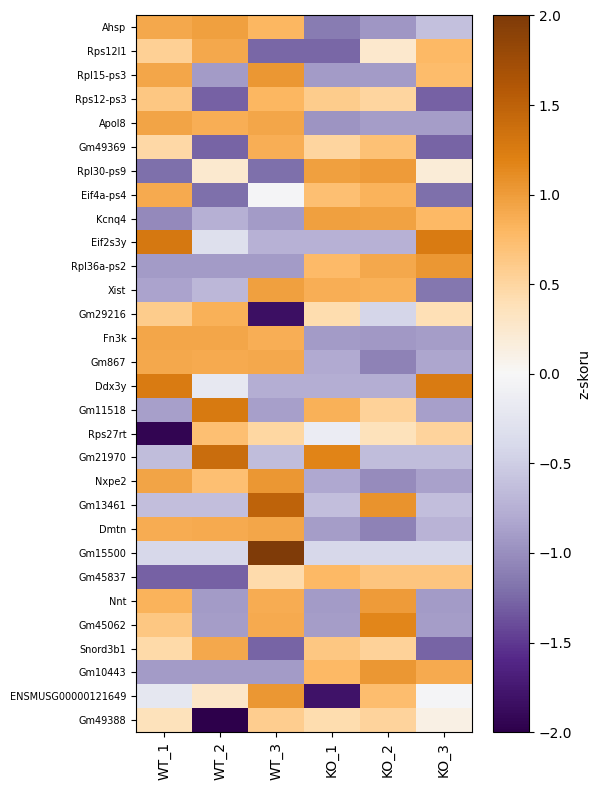

In [5]:
ad = t.set_index('gen_id')['gen_adi']
top30 = degisken.head(30).index
z = ln.loc[top30]
z = z.sub(z.mean(axis=1), axis=0).div(z.std(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(6, 8))
im = ax.pcolormesh(z.values, cmap='PuOr_r', vmin=-2, vmax=2)
ax.set_xticks(np.arange(6) + 0.5); ax.set_xticklabels(ornekler, rotation=90)
ax.set_yticks(np.arange(30) + 0.5); ax.set_yticklabels(ad.loc[top30], fontsize=7)
ax.invert_yaxis()
plt.colorbar(im, label='z-skoru')
plt.tight_layout();

## 5. Haritayı okuma

Listede üç tabaka var. Birincisi tanıdıklar: en tepede Ahsp, çevresinde Apol8, Fn3k, Dmtn, Kcnq4, Nxpe2 — volkanın yıldızları. Kimse onlara "anlamlı" demedi; buraya kendi varyanslarıyla geldiler, ve gözetimsiz haritanın gözetimli sonucu doğrulaması güven vericidir. İkincisi, adı -ps ya da Gm ile başlayan kalabalık: sahte genler ve tanımsız gen modelleri; haritalama gürültüsüne yatkındırlar, varlıkları not edilir ama üzerlerine tek başına hüküm kurulmaz. Üçüncüsü, bu deneyin hikâyesine ait görünmeyen üç isim: **Xist, Ddx3y, Eif2s3y.** Onlar sizin göreviniz.

## Kendin dene

Üç görev. Birincisi: kendi koşunuzdan ilk üç varyans payını ve PC tablosunu not edin — PC1 iki grubu ayırıyor mu, WT_3 kimin yanında, ve tek cümleyle: derinlik neden bir eksen kuramadı? İkincisi: Xist, Ddx3y ve Eif2s3y'nin örnek başına normalize değerlerini çekin (`norm` tablosundan; ad→kimlik çevirisi için yedinci rehberdeki `gen()` alışkanlığı iş görür), altı örneğin her birine bu üç satıra bakarak bir etiket verin ve künyeye eklenmesi gereken sütunun adını koyun — bir örnek kurala uymayacak; hangisi olduğunu ve üç genin onun için ne söylediğini de yazın. Üçüncüsü: bu yeni değişkenin gruplara dağılımına bakın ve iki kısa cümle yazın — genotiple karışmış mı, ve bu dağılım Rehber 8'in sonuçları için neden önemli?